In [1]:
### Import all necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
### load the dataset
df=pd.read_excel("glass.xlsx",sheet_name=1)

In [3]:
### Size of Data
df.shape

(214, 10)

In [4]:
### Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
#### first five rows
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


### 1. EDA

In [6]:
### Check Duplicates
df.duplicated().sum()

np.int64(1)

In [7]:
### Remove Duplicate
df.drop_duplicates(inplace=True,ignore_index=True)

In [8]:
####After dropping Duplicates
### Check Duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
### Check Missing values
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

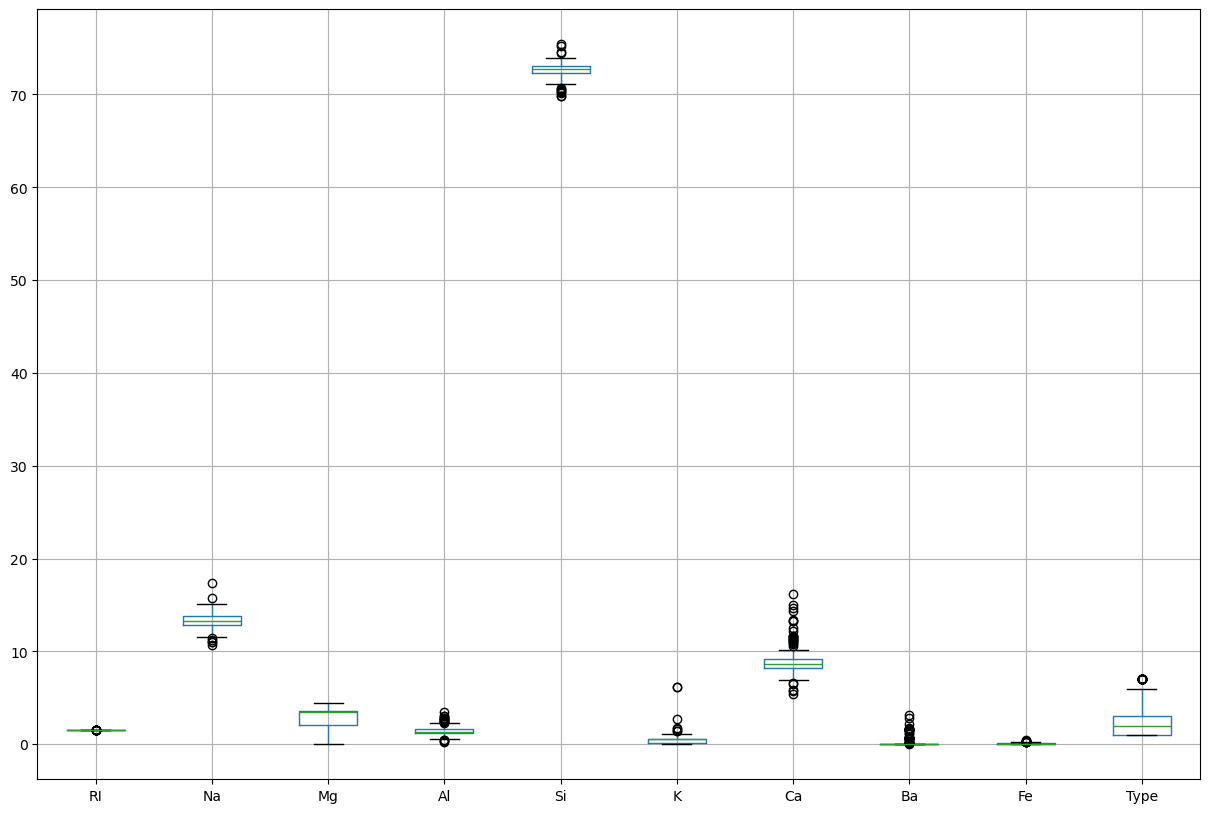

In [10]:
### Check outliers
plt.figure(figsize=(15,10))
df.boxplot()
plt.show()

In [11]:
### Outlier Capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

cols=['RI','Na','Al','Si','K','Ca','Fe']
for col in cols:
    outlier_capping(df,col)

* Outlier capping was applied to the RI, Na, Al, Si, K, Ca, and Fe features using the IQR method.
* The Ba feature was not capped because it contains mostly zero values. Capping it would make all values zero, resulting in the loss of important information.

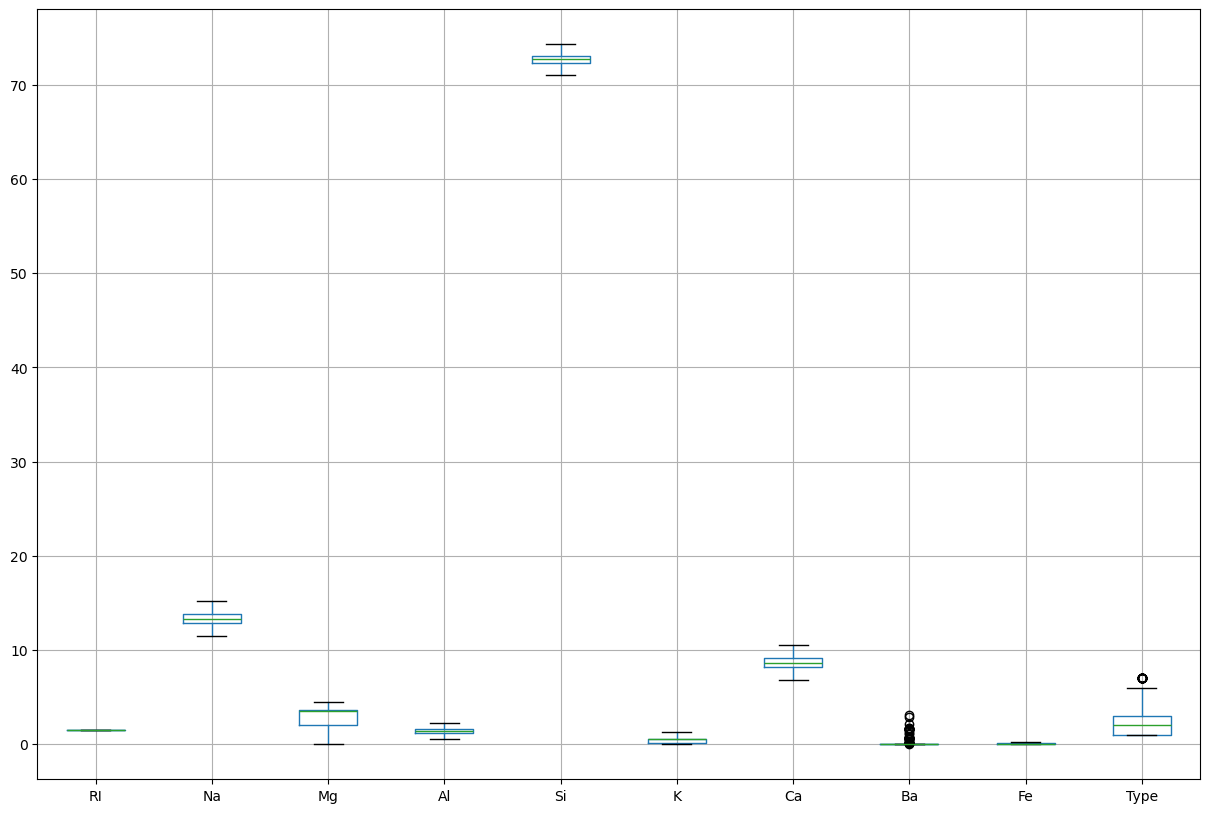

In [13]:
### After capping
### Check outliers
plt.figure(figsize=(15,10))
df.boxplot()
plt.show()

### 2. Data Visualization

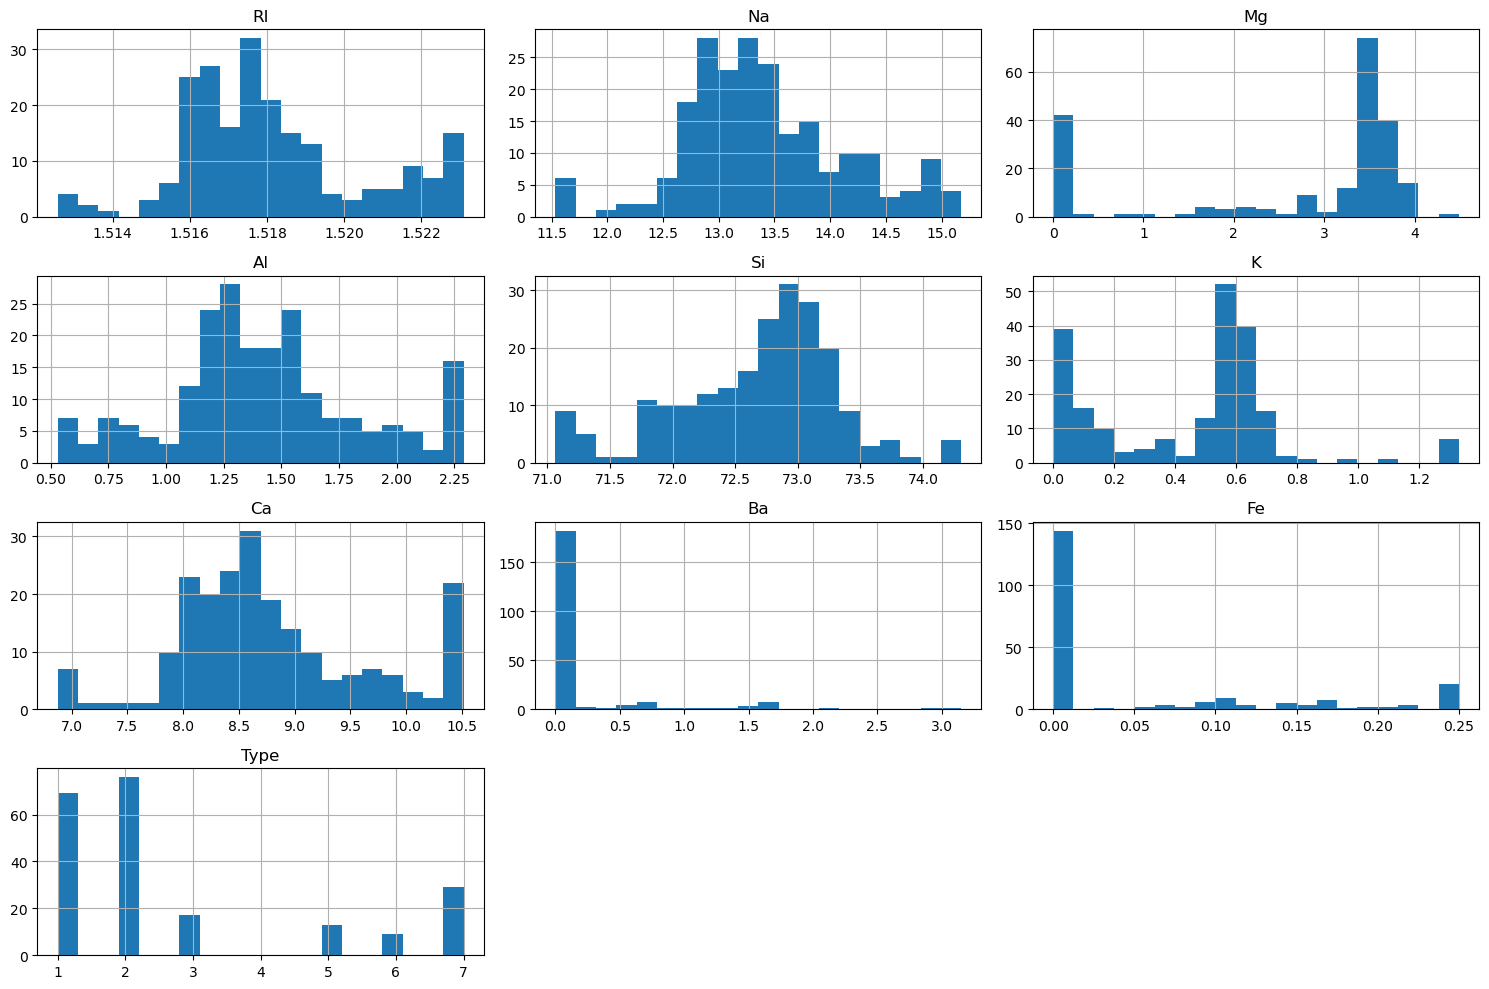

In [14]:
### Histogram
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

* Most features are not perfectly normally distributed.
* Some features such as Ba and Fe contain many zero values.
* A few features show skewness and possible outliers.
* The target variable is imbalanced, so this should be considered during model evaluation.

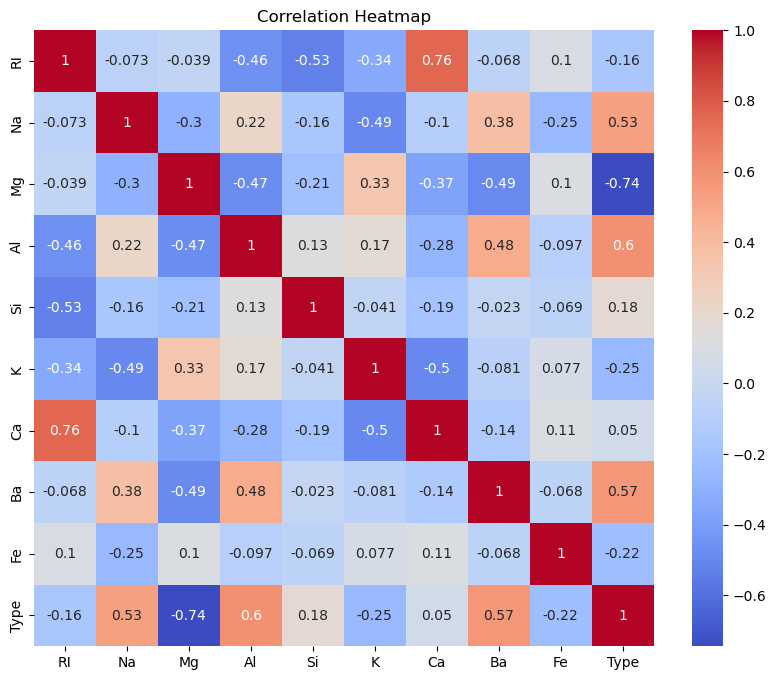

In [15]:
### Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

* RI and Ca have a strong positive relationship.
* Mg has a strong negative relationship with the glass Type.
* Na, Al, and Ba show a moderate positive relationship with the target variable.
* Most of the other features have weak relationships with each other.
* Overall, there is no very strong correlation among most features, which means each feature provides different information for predicting the glass type.

### 3. Data Preprocessing

#### Encoding

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      213 non-null    float64
 1   Na      213 non-null    float64
 2   Mg      213 non-null    float64
 3   Al      213 non-null    float64
 4   Si      213 non-null    float64
 5   K       213 non-null    float64
 6   Ca      213 non-null    float64
 7   Ba      213 non-null    float64
 8   Fe      213 non-null    float64
 9   Type    213 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


    The dataset contains only numerical features.

    No categorical variables are present, so encoding is not required.

In [24]:
### Scaling

target = df['Type']
features = df.drop('Type', axis=1)

std_sca=StandardScaler()
features1=pd.DataFrame(std_sca.fit_transform(features),columns=features.columns)

features1.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.216093,0.322680,1.257238,-0.773927,-1.361078,-1.253536,-0.044419,-0.353808,-0.621102
1,-0.227207,0.660556,0.639311,-0.154741,0.086641,0.124799,-1.115733,-0.353808,-0.621102
2,-0.834242,0.174014,0.604596,0.273927,0.482859,-0.170559,-1.173956,-0.353808,-0.621102
3,-0.205982,-0.258467,0.701798,-0.321445,-0.096228,0.420156,-0.661589,-0.353808,-0.621102
4,-0.307862,-0.177377,0.653197,-0.440519,0.620012,0.354521,-0.836260,-0.353808,-0.621102


#### Class imbalance Check

In [25]:
target.value_counts()

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64

* The number of samples is different for each glass type.
* Types 1 and 2 have more samples than the other glass types.
* Types 5 and 6 have fewer samples.
* This shows that the dataset is slightly imbalanced.
* To keep the same class distribution in both the training and testing data, stratified sampling was used.

### 4. Random Forest Model Implementation

In [30]:
### Train_Test_Split
x_train,x_test,y_train,y_test= train_test_split(features,target,train_size=0.8,random_state=100,stratify=target)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(170, 9)
(43, 9)
(170,)
(43,)


In [44]:
### Model Building
rf = RandomForestClassifier(n_estimators=100,random_state=100)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7906976744186046

    The Random Forest model achieved an accuracy of 79.07% on the test data.

In [34]:
### Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.78      0.93      0.85        15
           3       0.00      0.00      0.00         3
           5       1.00      0.33      0.50         3
           6       1.00      1.00      1.00         2
           7       0.83      0.83      0.83         6

    accuracy                           0.79        43
   macro avg       0.73      0.66      0.66        43
weighted avg       0.75      0.79      0.75        43



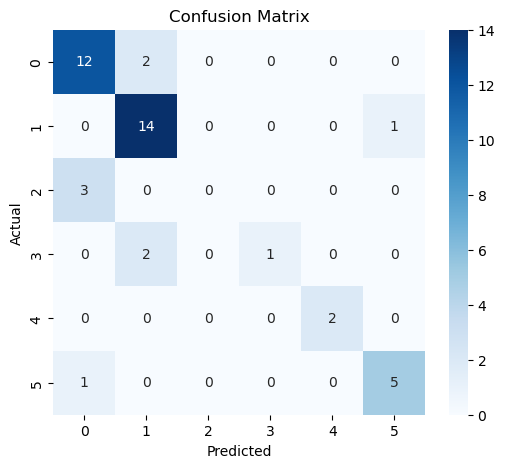

In [33]:
### Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

* The confusion matrix shows that the Random Forest model correctly classified most of the glass samples.
* A few samples were classified into the wrong glass type.
* The model performed well for Types 1, 2, 5, and 6, with most predictions being correct.
* Misclassifications occurred because some glass types have similar characteristics.
* Overall, the model shows good classification performance with only a few prediction errors.

### 5. Bagging and Boosting Methods

In [39]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

In [46]:
### Bagging
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=100),n_estimators=100,random_state=100)

bagging.fit(x_train, y_train)

bag_pred = bagging.predict(x_test)
bag_accuracy = accuracy_score(y_test, bag_pred)
bag_accuracy

0.7674418604651163

    The Bagging model achieved an accuracy of 76.74% on the test data.

In [47]:
### Boosting
base_estimator = DecisionTreeClassifier(max_depth=3, random_state=100)

boost = AdaBoostClassifier(estimator=base_estimator,n_estimators=100,random_state=100)
boost.fit(x_train, y_train)
boost_pred = boost.predict(x_test)
boost_accuracy = accuracy_score(y_test, boost_pred)
boost_accuracy

0.7441860465116279

    The Boosting model achieved an accuracy of 74.42% on the test data.

In [48]:
### Comparison
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Bagging", "AdaBoost"],
    "Accuracy": [accuracy, bag_accuracy, boost_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest,0.790698
1,Bagging,0.767442
2,AdaBoost,0.744186


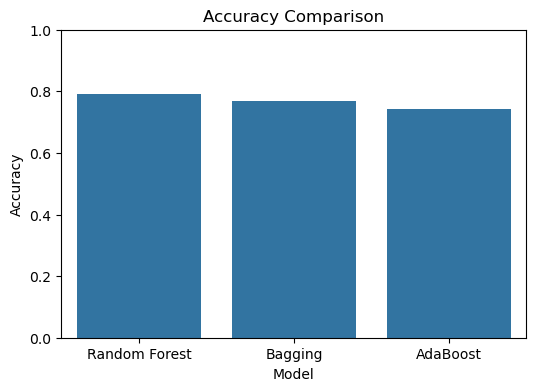

In [49]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Model", y="Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

* Random Forest gave the highest accuracy among the three models.
* Bagging also performed well, but its accuracy was slightly lower than Random Forest.
* AdaBoost achieved the lowest accuracy compared to the other two models.
* Overall, Random Forest is the best model for predicting the glass types in this dataset.

### Additional Notes

#### 1. Explain Bagging and Boosting methods. How is it different from each other.

**Bagging**

Bagging is an ensemble learning technique in which multiple models are trained on different random samples of the training data. Each model makes its own prediction independently, and the final prediction is obtained by majority voting (for classification) or averaging (for regression). Bagging helps improve model stability and reduces overfitting.

**Boosting**

Boosting is an ensemble learning technique in which models are trained sequentially. Each new model focuses on the samples that were incorrectly predicted by the previous model. The final prediction is made by combining the predictions of all models. Boosting helps improve prediction accuracy by reducing errors.

#### Difference 
**Bagging**
* Bagging trains multiple models independently on different random samples of the training data.
* All models are trained at the same time.
* Each model has equal importance in making the final prediction.
* The final prediction is made using majority voting (classification) or averaging (regression).
* It mainly helps to reduce overfitting and improve model stability.
* Example: Random Forest, Bagging Classifier.
    
**Boosting**
* Boosting trains multiple models sequentially (one after another).
* Each new model focuses on correcting the mistakes made by the previous model.
* Models are not equally important; later models give more attention to previously misclassified samples.
* The final prediction is made by combining the weighted predictions of all models.
* It mainly helps to reduce prediction errors and improve model accuracy.
* Example: AdaBoost, Gradient Boosting, XGBoost.

#### 2. Explain how to handle imbalance in the data.

* **Oversampling:** Increase the number of samples in the minority class so that all classes have a similar number of records.
* **Undersampling:** Reduce the number of samples in the majority class to balance the dataset.
* **Stratified Sampling:** Split the dataset so that the training and testing data have the same class distribution as the original dataset.
* **Class Weights:** Give more importance to the minority class during model training so that the model learns all classes more effectively.
* **Use Better Evaluation Metrics:** Along with accuracy, use Precision, Recall, and F1-score because they provide a better evaluation of models trained on imbalanced data.

In [ ]:
### Conclusion
The Glass dataset was analyzed using Exploratory Data Analysis (EDA) and data visualization techniques.
Missing values, outliers, feature scaling, and class imbalance were checked during data preprocessing.
Three ensemble models—Random Forest, Bagging, and AdaBoost—were trained and evaluated.
Among these models, Random Forest achieved the highest accuracy (79.07%), followed by Bagging (76.74%) and AdaBoost (74.42%).
Based on the results, Random Forest performed the best for classifying the glass types in this dataset.